<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/notebooks/03_bow_ngrams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QPon Reviews — Bag of Words, N-Grams & Regex

| | |
|---|---|
| **Input** | `qpon_preprocessed.csv` |
| **Output** | `bow_features.csv`, `bow_cleaned.csv` |
| **Author** | Zeldano Shan Oeffie (5026231118) |

Feature extraction from preprocessed QPon reviews using Bag of Words,
regular expressions, and N-gram analysis.

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

---
## 1. Load Preprocessed Data

In [2]:
df = pd.read_csv('qpon_preprocessed.csv')
df['processed'] = df['processed'].fillna('')
print(f'{len(df):,} reviews loaded')
df[['content', 'processed', 'sentiment']].head()

4,659 reviews loaded


,content,processed,sentiment
0,keren,keren,positive
1,tukar vocer qpon saldo udah kepotong status be...,tukar vocer qpon saldo potong status bayar bay...,negative
2,"promonya kurang masih mahal, murahan jga tiktok",promonya mahal murah jga tiktok,negative
3,very good .. all in one..,very good all in one,positive
4,"UNINSTALL AJA GUYS MAKIN LAMA MAKIN JELEK, MAK...",uninstall guys jelek aneh voucher rb besok che...,negative


---
## 2. Regex Exploration
Using regular expressions to find specific patterns in the raw review text.

In [3]:
raw = df['content'].astype(str)

# find reviews mentioning error codes or specific issues
err_pattern = r'error|gagal|crash|bug|stuck|loading'
promo_pattern = r'promo|cashback|diskon|voucher|kupon|kode'

df['mentions_error'] = raw.str.contains(err_pattern, case=False, na=False)
df['mentions_promo'] = raw.str.contains(promo_pattern, case=False, na=False)

print('Error-related reviews:', df['mentions_error'].sum())
print('Promo-related reviews:', df['mentions_promo'].sum())
print()

# average rating for each group
for col, label in [('mentions_error', 'Error'), ('mentions_promo', 'Promo')]:
    avg = df.groupby(col)['score'].mean()
    print(f'{label} mentions — avg rating: {avg.get(True, 0):.2f} vs others: {avg.get(False, 0):.2f}')

Error-related reviews: 137
Promo-related reviews: 1690

Error mentions — avg rating: 1.55 vs others: 3.01
Promo mentions — avg rating: 3.32 vs others: 2.77


In [4]:
# extract version numbers mentioned in reviews
df['version_mention'] = raw.str.extract(r'(v?\d+\.\d+\.?\d*)', expand=False)

version_counts = df['version_mention'].dropna().value_counts().head(10)
if len(version_counts) > 0:
    print('Most mentioned versions:')
    print(version_counts)
else:
    print('No version numbers found in reviews')

Most mentioned versions:
version_mention
1.000         6
50.000        3
8.8           2
11.00         2
02.02.2026    1
68.000        1
20.32         1
16.15         1
12.00         1
14.30         1
Name: count, dtype: int64


---
## 3. Bag of Words

In [5]:
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(df['processed'])
vocab = vectorizer.get_feature_names_out()

print(f'Documents : {bow_matrix.shape[0]:,}')
print(f'Vocabulary: {bow_matrix.shape[1]:,} unique terms')
print(f'Sparsity  : {(1 - bow_matrix.nnz / (bow_matrix.shape[0]*bow_matrix.shape[1])):.2%}')

Documents : 4,659
Vocabulary: 4,884 unique terms
Sparsity  : 99.81%


In [6]:
# preview first 10 docs x 15 terms
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vocab)
bow_df.iloc[:10, :15]

,aaaaah,aaaahhhh,aahh,aamiin,aapa,aba,abai,abal,abang,abb,abis,abiss,abnormal,abrnormal,abs
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


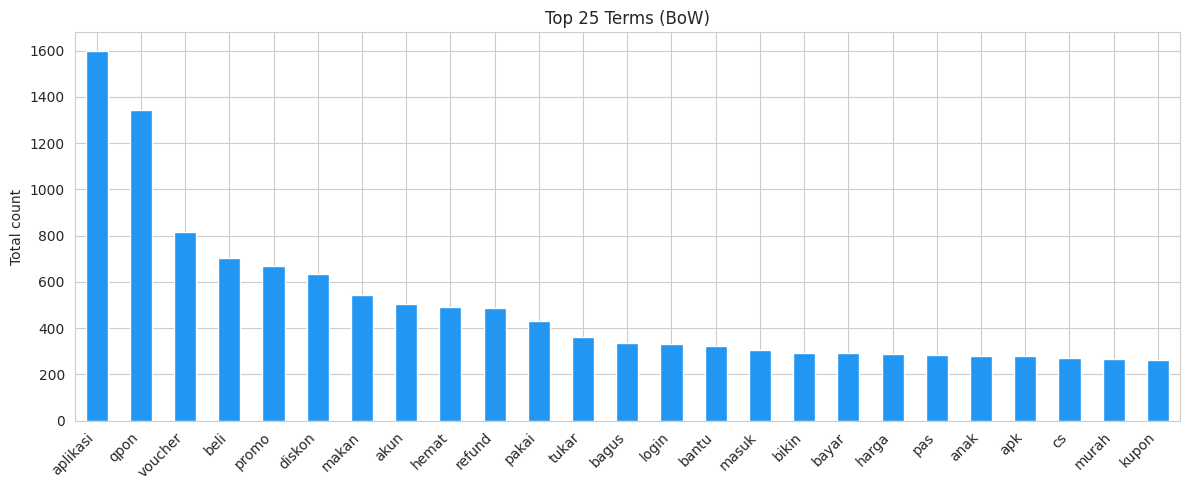

In [7]:
# top terms by total count
term_freq = bow_df.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
term_freq.head(25).plot.bar(ax=ax, color='#2196F3')
ax.set_title('Top 25 Terms (BoW)')
ax.set_ylabel('Total count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
bow_df.to_csv('bow_features.csv', index=False)
print(f'Saved bow_features.csv — {bow_df.shape}')

Saved bow_features.csv — (4659, 4884)


In [9]:
# remove words that appear only once (likely typos)
word_totals = bow_df.sum()
rare = word_totals[word_totals <= 1].index
bow_clean = bow_df.drop(columns=rare)

print(f'Before: {bow_df.shape[1]:,} terms')
print(f'Removed: {len(rare):,} rare terms')
print(f'After : {bow_clean.shape[1]:,} terms')

bow_clean.to_csv('bow_cleaned.csv', index=False)
print(f'\nSaved bow_cleaned.csv')

Before: 4,884 terms
Removed: 2,676 rare terms
After : 2,208 terms

Saved bow_cleaned.csv


---
## 4. N-Gram Analysis

In [10]:
# bigrams
vec_bi = CountVectorizer(ngram_range=(2, 2))
bi_matrix = vec_bi.fit_transform(df['processed'])
bi_freq = pd.Series(bi_matrix.toarray().sum(axis=0), index=vec_bi.get_feature_names_out())
bi_top = bi_freq.sort_values(ascending=False).head(20)

# trigrams
vec_tri = CountVectorizer(ngram_range=(3, 3))
tri_matrix = vec_tri.fit_transform(df['processed'])
tri_freq = pd.Series(tri_matrix.toarray().sum(axis=0), index=vec_tri.get_feature_names_out())
tri_top = tri_freq.sort_values(ascending=False).head(20)

print(f'Unique bigrams : {len(bi_freq):,}')
print(f'Unique trigrams: {len(tri_freq):,}')

Unique bigrams : 27,148
Unique trigrams: 34,424


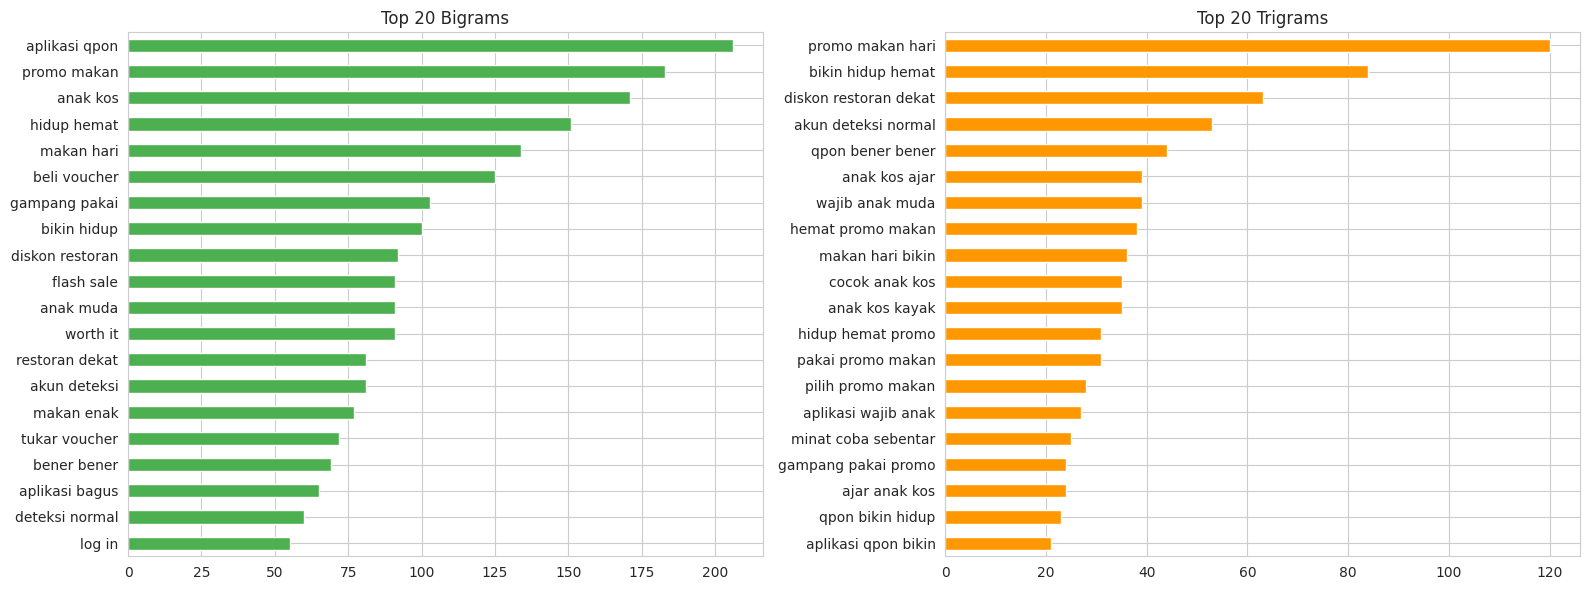

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bi_top.plot.barh(ax=axes[0], color='#4CAF50')
axes[0].set_title('Top 20 Bigrams')
axes[0].invert_yaxis()

tri_top.plot.barh(ax=axes[1], color='#FF9800')
axes[1].set_title('Top 20 Trigrams')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

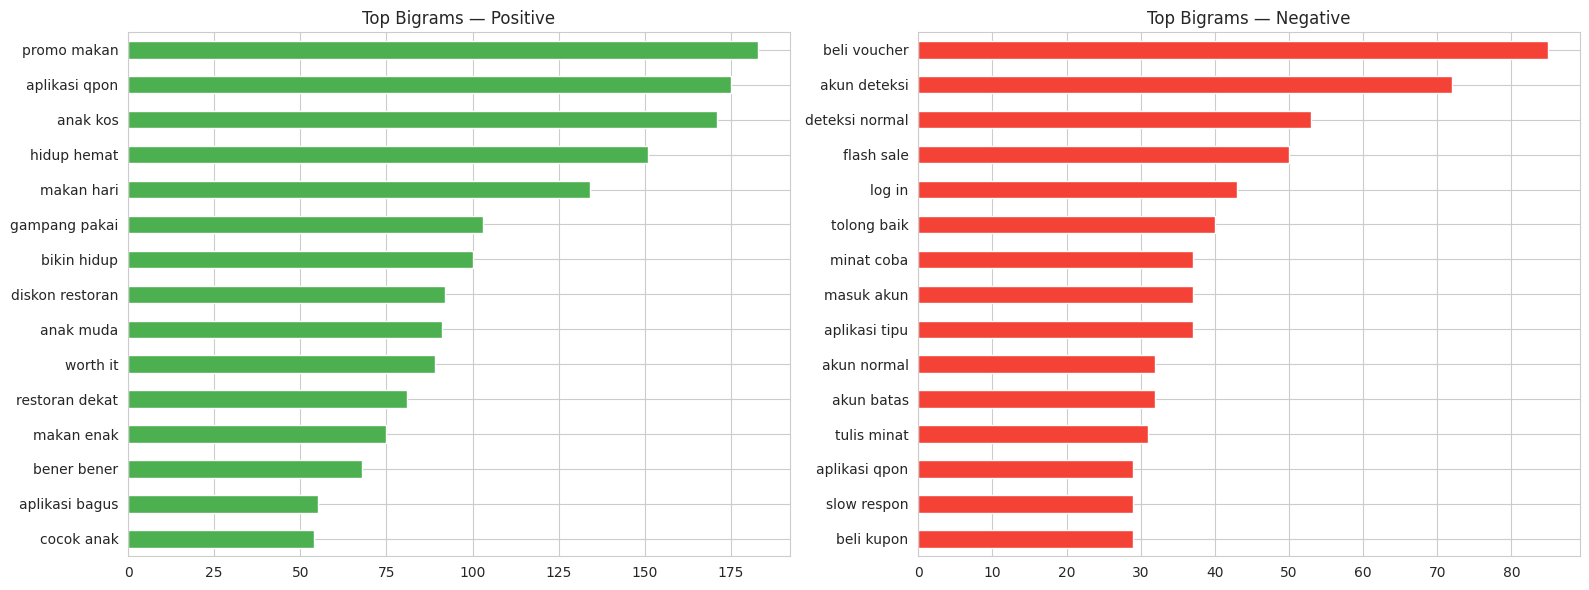

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sent, color in zip(axes, ['positive', 'negative'], ['#4CAF50', '#F44336']):
    subset = df[df['sentiment'] == sent]['processed']
    v = CountVectorizer(ngram_range=(2, 2))
    m = v.fit_transform(subset)
    f = pd.Series(m.toarray().sum(axis=0), index=v.get_feature_names_out())
    top = f.sort_values(ascending=False).head(15)
    top.plot.barh(ax=ax, color=color)
    ax.set_title(f'Top Bigrams — {sent.title()}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## Summary

**Regex patterns** identified error-related and promo-related reviews — error mentions correlate with lower ratings.

**Bag of Words:**
- Full vocabulary from preprocessed text, saved as `bow_features.csv`
- Cleaned version (rare words removed) saved as `bow_cleaned.csv`

**N-grams** reveal common multi-word phrases:
- Bigrams and trigrams differ significantly between positive and negative reviews
- Positive: promo-related phrases
- Negative: error/complaint-related phrases
